In [338]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [339]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [340]:
regular_season_outcomes = pd.read_csv('/content/drive/MyDrive/ChicagoBears/TeamStats/2025RegularSeason.csv')
regular_season_outcomes

,Rk,Gtm,Week,Date,Day,HomeAway,Opp,Rslt,Pts,PtsO,OT,Cmp,PassAtt,Cmp%,PassYds,PassTD,Pass_Y/A,AY/A,Rate,Sk,SackYds,RushAtt,RushYds,RushTD,Rush_Y/A,Ply,Tot,Y/P,FGA,FGM,XPA,XPM,Pnt,PuntYds,FD_Pass,FD_Rsh,FD_Pen,1stD,3DConv,3DAtt,4DConv,4DAtt,Pen,PenYds,FL,Int,TO,ToP
0,1.0,1.0,1.0,2025-09-08,Mon,NaN,MIN,L,24,27,NaN,21,35,60.0,198,1,5.7,6.2,85.2,2,12,26,119,1,4.6,63,317,5.03,2,1,3,3,6,266,10,7,3,20,3,12,0,1,12,127,1,0,1,32:53
1,2.0,2.0,2.0,2025-09-14,Sun,@,DET,L,21,52,NaN,21,33,63.6,205,2,6.2,6.1,88.6,4,29,27,134,1,5.0,64,339,5.30,0,0,3,3,4,212,11,7,1,19,7,13,0,2,8,50,1,1,2,29:40
2,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,19,28,67.9,298,4,10.6,13.5,142.6,0,0,29,87,0,3.0,57,385,6.75,1,1,4,4,4,176,11,7,1,19,8,14,1,1,6,41,0,0,0,27:02
3,4.0,4.0,4.0,2025-09-28,Sun,@,LVR,W,25,24,NaN,22,37,59.5,202,1,5.5,4.8,72.1,1,10,26,69,1,2.7,64,271,4.23,4,4,1,1,3,148,10,5,1,16,7,16,1,1,8,60,0,1,1,33:10
4,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,17,29,58.6,236,1,8.1,8.8,96.3,3,16,27,150,1,5.6,59,386,6.54,5,4,1,1,2,106,10,8,1,19,3,10,0,1,9,84,0,0,0,28:26
5,6.0,6.0,7.0,2025-10-19,Sun,NaN,NOR,W,26,14,NaN,15,26,57.7,164,0,6.3,4.6,60.4,1,8,40,222,2,5.6,67,386,5.76,4,4,2,2,3,129,10,13,0,23,3,12,1,1,10,92,0,1,1,36:19
6,7.0,7.0,8.0,2025-10-26,Sun,@,BAL,L,16,30,NaN,25,38,65.8,276,0,7.3,6.1,76.2,1,9,23,96,1,4.2,62,372,6.00,4,3,1,1,2,108,13,5,1,19,6,13,0,1,11,79,0,1,1,29:30
7,8.0,8.0,9.0,2025-11-02,Sun,@,CIN,W,47,42,NaN,22,37,59.5,293,4,7.9,10.1,120.7,2,9,37,283,2,7.6,76,576,7.58,3,2,5,5,2,117,17,11,2,30,8,15,2,2,7,43,0,0,0,34:30
8,9.0,9.0,10.0,2025-11-09,Sun,NaN,NYG,W,24,20,NaN,20,36,55.6,220,1,6.1,6.7,83.1,0,0,28,171,2,6.1,64,391,6.11,1,1,3,3,3,135,11,8,4,23,3,11,1,4,3,25,0,0,0,28:42
9,10.0,10.0,11.0,2025-11-16,Sun,@,MIN,W,19,17,NaN,16,32,50.0,180,0,5.6,5.6,67.2,2,13,39,140,1,3.6,73,320,4.38,5,4,1,1,6,286,6,13,0,19,7,18,0,0,6,40,0,0,0,36:59


In [341]:
opponent_regular_season_outcomes = pd.read_csv('/content/drive/MyDrive/ChicagoBears/TeamStats/Opponent2025RegularSeason.csv')
opponent_regular_season_outcomes['ToP']

all_reg_season_outcomes = regular_season_outcomes.join(opponent_regular_season_outcomes, lsuffix = 'Chi', rsuffix = 'Opp')
all_ToP = all_reg_season_outcomes[['RsltChi','ToPChi','ToPOpp']]
all_ToP = all_ToP.iloc[0:17]
all_ToP

,RsltChi,ToPChi,ToPOpp
0,L,32:53,27:07
1,L,29:40,30:20
2,W,27:02,32:58
3,W,33:10,26:50
4,W,28:26,31:34
5,W,36:19,23:41
6,L,29:30,30:30
7,W,34:30,25:30
8,W,28:42,31:18
9,W,36:59,23:01


In [342]:
# Helper function to convert MM:SS string to seconds
def convert_to_seconds(time_str):
    if pd.isna(time_str): # Handle NaN values if any
        return np.nan
    parts = str(time_str).split(':')
    if len(parts) == 2:
        minutes, seconds = int(parts[0]), int(parts[1])
        return minutes * 60 + seconds
    return np.nan # Return NaN for invalid formats

# Convert 'ToPChi' and 'ToPOpp' to seconds
all_ToP['ToPChi_seconds'] = all_ToP['ToPChi'].apply(convert_to_seconds)
all_ToP['ToPOpp_seconds'] = all_ToP['ToPOpp'].apply(convert_to_seconds)

# Calculate the difference using a lambda function
all_ToP['ToP_Diff'] = all_ToP.apply(lambda row: row['ToPChi_seconds'] - row['ToPOpp_seconds'], axis=1)

# Display the updated DataFrame
display(all_ToP)

,RsltChi,ToPChi,ToPOpp,ToPChi_seconds,ToPOpp_seconds,ToP_Diff
0,L,32:53,27:07,1973,1627,346
1,L,29:40,30:20,1780,1820,-40
2,W,27:02,32:58,1622,1978,-356
3,W,33:10,26:50,1990,1610,380
4,W,28:26,31:34,1706,1894,-188
5,W,36:19,23:41,2179,1421,758
6,L,29:30,30:30,1770,1830,-60
7,W,34:30,25:30,2070,1530,540
8,W,28:42,31:18,1722,1878,-156
9,W,36:59,23:01,2219,1381,838


In [343]:
# Calculate the average Time of Possession for wins and losses
average_top_by_result = all_ToP.groupby('RsltChi')['ToPChi_seconds'].mean().reset_index()

# Calculate the difference in average Time of Possession between wins and losses
# Ensure 'W' and 'L' results exist before trying to access them
win_top = average_top_by_result[average_top_by_result['RsltChi'] == 'W']['ToPChi_seconds'].iloc[0]
loss_top = average_top_by_result[average_top_by_result['RsltChi'] == 'L']['ToPChi_seconds'].iloc[0]

difference_in_top_mins = (win_top - loss_top) / 60

/tmp/ipykernel_39935/1937691637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RsltChi', y='ToPChi_seconds', data=average_top_by_result, palette={'L': 'salmon', 'W': 'lightgreen'})


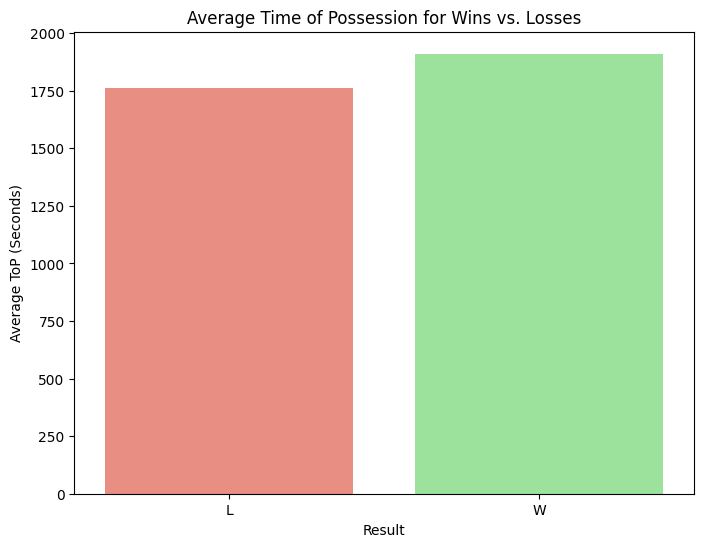

The difference in average Time of Possession between wins and losses is approximately 2.48 minutes for the Chicago Bears.


In [344]:
# Create a bar plot to visualize the average Time of Possession for wins and losses
plt.figure(figsize=(8, 6))
sns.barplot(x='RsltChi', y='ToPChi_seconds', data=average_top_by_result, palette={'L': 'salmon', 'W': 'lightgreen'})
plt.title('Average Time of Possession for Wins vs. Losses')
plt.xlabel('Result')
plt.ylabel('Average ToP (Seconds)')
plt.show()

print(f"The difference in average Time of Possession between wins and losses is approximately {difference_in_top_mins:.2f} minutes for the Chicago Bears.")

In [345]:
unexpected_wins = all_ToP[(all_ToP['RsltChi'] == 'W') & (all_ToP['ToP_Diff'] < 0)]
unexpected_wins_count = len(unexpected_wins)
unexpected_wins_count

5

In [346]:
expected_wins = all_ToP[(all_ToP['RsltChi'] == 'W') & (all_ToP['ToP_Diff'] > 0)]
expected_wins_count = len(expected_wins)
expected_wins_count

6

In [347]:
expected_losses = all_ToP[(all_ToP['RsltChi'] == 'L') & (all_ToP['ToP_Diff'] < 0)]
expected_losses_count = len(expected_losses)
expected_losses_count

4

In [348]:
unexpected_losses = all_ToP[(all_ToP['RsltChi'] == 'L') & (all_ToP['ToP_Diff'] > 0)]
unexpected_losses_count = len(unexpected_losses)
unexpected_losses_count

2

Based on the analysis, there's no certain evidence that time of possession alone dictates a victory or a loss for the Bears. It's intriguing that the Bears do not necessarily need a larger time of possession than their opponent to secure a win. However, it was observed that only two losses occurred when the Bears had more time of possession, which generally aligns with the assumption that a lower time of possession often leads to a loss.

In [349]:
all_reg_season_outcomes['ToP_Diff'] = all_ToP['ToP_Diff']
display(all_reg_season_outcomes.head())

,RkChi,GtmChi,WeekChi,DateChi,DayChi,HomeAwayChi,OppChi,RsltChi,PtsChi,PtsOChi,OTChi,CmpChi,PassAttChi,Cmp%Chi,PassYdsChi,PassTDChi,Pass_Y/AChi,AY/AChi,RateChi,SkChi,SackYdsChi,RushAttChi,RushYdsChi,RushTDChi,Rush_Y/AChi,PlyChi,TotChi,Y/PChi,FGAChi,FGMChi,XPAChi,XPMChi,PntChi,PuntYdsChi,FD_PassChi,FD_RshChi,FD_PenChi,1stDChi,3DConvChi,3DAttChi,4DConvChi,4DAttChi,PenChi,PenYdsChi,FLChi,IntChi,TOChi,ToPChi,RkOpp,GtmOpp,WeekOpp,DateOpp,DayOpp,HomeAwayOpp,OppOpp,RsltOpp,PtsOpp,PtsOOpp,OTOpp,CmpOpp,PassAttOpp,Cmp%Opp,PassYdsOpp,PassTDOpp,Pass_Y/AOpp,AY/AOpp,RateOpp,SkOpp,SackYdsOpp,RushAttOpp,RushYdsOpp,RushTDOpp,Rush_Y/AOpp,PlyOpp,TotOpp,Y/POpp,FGAOpp,FGMOpp,XPAOpp,XPMOpp,PntOpp,PuntYdsOpp,FD_PassOpp,FD_RshOpp,FD_PenOpp,1stDOpp,3DConvOpp,3DAttOpp,4DConvOpp,4DAttOpp,PenOpp,PenYdsOpp,FLOpp,IntOpp,TOOpp,ToPOpp,ToP_Diff
0,1.0,1.0,1.0,2025-09-08,Mon,NaN,MIN,L,24,27,NaN,21,35,60.0,198,1,5.7,6.2,85.2,2,12,26,119,1,4.6,63,317,5.03,2,1,3,3,6,266,10,7,3,20,3,12,0,1,12,127,1,0,1,32:53,1.0,1.0,1.0,2025-09-08,Mon,NaN,MIN,L,24,27,NaN,13,20,65.0,134,2,6.7,6.5,96.7,3,9,26,120,1,4.6,49,254,5.18,2,2,1,1,7,333,5,6,3,14,3,12,0,0,8,50,0,1,1,27:07,346.0
1,2.0,2.0,2.0,2025-09-14,Sun,@,DET,L,21,52,NaN,21,33,63.6,205,2,6.2,6.1,88.6,4,29,27,134,1,5.0,64,339,5.30,0,0,3,3,4,212,11,7,1,19,7,13,0,2,8,50,1,1,2,29:40,2.0,2.0,2.0,2025-09-14,Sun,@,DET,L,21,52,NaN,23,28,82.1,334,5,11.9,15.5,156.0,0,0,30,177,2,5.9,58,511,8.81,2,1,7,7,3,147,15,10,0,25,4,10,1,1,3,28,0,0,0,30:20,-40.0
2,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,19,28,67.9,298,4,10.6,13.5,142.6,0,0,29,87,0,3.0,57,385,6.75,1,1,4,4,4,176,11,7,1,19,8,14,1,1,6,41,0,0,0,27:02,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,34,45,75.6,275,1,6.1,3.6,70.1,2,17,20,121,0,6.1,67,396,5.91,2,2,0,0,2,102,14,6,3,23,3,11,2,3,4,25,1,3,4,32:58,-356.0
3,4.0,4.0,4.0,2025-09-28,Sun,@,LVR,W,25,24,NaN,22,37,59.5,202,1,5.5,4.8,72.1,1,10,26,69,1,2.7,64,271,4.23,4,4,1,1,3,148,10,5,1,16,7,16,1,1,8,60,0,1,1,33:10,4.0,4.0,4.0,2025-09-28,Sun,@,LVR,W,25,24,NaN,14,21,66.7,117,2,5.6,1.0,73.0,0,0,31,240,1,7.7,52,357,6.87,2,1,3,3,1,60,6,10,1,17,2,8,0,1,5,36,1,3,4,26:50,380.0
4,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,17,29,58.6,236,1,8.1,8.8,96.3,3,16,27,150,1,5.6,59,386,6.54,5,4,1,1,2,106,10,8,1,19,3,10,0,1,9,84,0,0,0,28:26,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,19,26,73.1,205,3,7.9,8.5,118.3,3,6,31,124,0,4.0,60,329,5.48,2,1,3,3,1,30,11,7,4,22,3,8,1,1,5,40,2,1,3,31:34,-188.0


In [350]:
unexpected_win = all_reg_season_outcomes[
    (all_reg_season_outcomes['RsltChi'] == 'W') &
    (all_reg_season_outcomes['ToP_Diff'] < 0)
]

unexpected_win

,RkChi,GtmChi,WeekChi,DateChi,DayChi,HomeAwayChi,OppChi,RsltChi,PtsChi,PtsOChi,OTChi,CmpChi,PassAttChi,Cmp%Chi,PassYdsChi,PassTDChi,Pass_Y/AChi,AY/AChi,RateChi,SkChi,SackYdsChi,RushAttChi,RushYdsChi,RushTDChi,Rush_Y/AChi,PlyChi,TotChi,Y/PChi,FGAChi,FGMChi,XPAChi,XPMChi,PntChi,PuntYdsChi,FD_PassChi,FD_RshChi,FD_PenChi,1stDChi,3DConvChi,3DAttChi,4DConvChi,4DAttChi,PenChi,PenYdsChi,FLChi,IntChi,TOChi,ToPChi,RkOpp,GtmOpp,WeekOpp,DateOpp,DayOpp,HomeAwayOpp,OppOpp,RsltOpp,PtsOpp,PtsOOpp,OTOpp,CmpOpp,PassAttOpp,Cmp%Opp,PassYdsOpp,PassTDOpp,Pass_Y/AOpp,AY/AOpp,RateOpp,SkOpp,SackYdsOpp,RushAttOpp,RushYdsOpp,RushTDOpp,Rush_Y/AOpp,PlyOpp,TotOpp,Y/POpp,FGAOpp,FGMOpp,XPAOpp,XPMOpp,PntOpp,PuntYdsOpp,FD_PassOpp,FD_RshOpp,FD_PenOpp,1stDOpp,3DConvOpp,3DAttOpp,4DConvOpp,4DAttOpp,PenOpp,PenYdsOpp,FLOpp,IntOpp,TOOpp,ToPOpp,ToP_Diff
2,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,19,28,67.9,298,4,10.6,13.5,142.6,0,0,29,87,0,3.0,57,385,6.75,1,1,4,4,4,176,11,7,1,19,8,14,1,1,6,41,0,0,0,27:02,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,34,45,75.6,275,1,6.1,3.6,70.1,2,17,20,121,0,6.1,67,396,5.91,2,2,0,0,2,102,14,6,3,23,3,11,2,3,4,25,1,3,4,32:58,-356.0
4,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,17,29,58.6,236,1,8.1,8.8,96.3,3,16,27,150,1,5.6,59,386,6.54,5,4,1,1,2,106,10,8,1,19,3,10,0,1,9,84,0,0,0,28:26,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,19,26,73.1,205,3,7.9,8.5,118.3,3,6,31,124,0,4.0,60,329,5.48,2,1,3,3,1,30,11,7,4,22,3,8,1,1,5,40,2,1,3,31:34,-188.0
8,9.0,9.0,10.0,2025-11-09,Sun,NaN,NYG,W,24,20,NaN,20,36,55.6,220,1,6.1,6.7,83.1,0,0,28,171,2,6.1,64,391,6.11,1,1,3,3,3,135,11,8,4,23,3,11,1,4,3,25,0,0,0,28:42,9.0,9.0,10.0,2025-11-09,Sun,NaN,NYG,W,24,20,NaN,22,36,61.1,262,0,7.3,7.3,83.3,4,25,30,169,2,5.6,70,431,6.16,2,2,2,2,3,110,11,8,2,21,5,14,1,4,10,69,1,0,1,31:18,-156.0
10,11.0,11.0,12.0,2025-11-23,Sun,NaN,PIT,W,31,28,NaN,19,35,54.3,229,3,6.5,8.3,103.2,1,10,25,99,1,4.0,61,328,5.38,1,1,4,4,4,202,11,7,1,19,7,13,1,1,7,83,2,0,2,26:51,11.0,11.0,12.0,2025-11-23,Sun,NaN,PIT,W,31,28,NaN,24,31,77.4,159,1,5.1,4.3,85.3,2,12,36,186,2,5.2,69,345,5.00,0,0,4,4,3,106,8,12,2,22,8,14,1,3,6,41,1,1,2,33:09,-378.0
14,15.0,15.0,16.0,2025-12-20,Sat,NaN,GNB,W,22,16,OT,19,34,55.9,250,2,7.4,8.5,98.9,0,0,26,150,0,5.8,60,400,6.67,3,3,1,1,3,125,10,8,2,20,2,11,2,3,10,105,0,0,0,26:13,15.0,15.0,16.0,2025-12-20,Sat,NaN,GNB,W,22,16,OT,17,24,70.8,192,1,8.0,8.8,108.3,2,6,44,192,0,4.4,70,384,5.49,3,3,1,1,0,0,10,11,3,24,6,12,1,3,4,40,1,0,1,38:57,-764.0


Based on these preliminary findings, it appears that Time of Possession alone doesn't definitively determine a win or loss for the Bears, especially given the 'unexpected' outcomes. It's now time to broaden our analysis and investigate other features or statistics that might have a stronger correlation with game results and help better determine a Bears' win.

In [351]:
regular_season_outcomes

,Rk,Gtm,Week,Date,Day,HomeAway,Opp,Rslt,Pts,PtsO,OT,Cmp,PassAtt,Cmp%,PassYds,PassTD,Pass_Y/A,AY/A,Rate,Sk,SackYds,RushAtt,RushYds,RushTD,Rush_Y/A,Ply,Tot,Y/P,FGA,FGM,XPA,XPM,Pnt,PuntYds,FD_Pass,FD_Rsh,FD_Pen,1stD,3DConv,3DAtt,4DConv,4DAtt,Pen,PenYds,FL,Int,TO,ToP
0,1.0,1.0,1.0,2025-09-08,Mon,NaN,MIN,L,24,27,NaN,21,35,60.0,198,1,5.7,6.2,85.2,2,12,26,119,1,4.6,63,317,5.03,2,1,3,3,6,266,10,7,3,20,3,12,0,1,12,127,1,0,1,32:53
1,2.0,2.0,2.0,2025-09-14,Sun,@,DET,L,21,52,NaN,21,33,63.6,205,2,6.2,6.1,88.6,4,29,27,134,1,5.0,64,339,5.30,0,0,3,3,4,212,11,7,1,19,7,13,0,2,8,50,1,1,2,29:40
2,3.0,3.0,3.0,2025-09-21,Sun,NaN,DAL,W,31,14,NaN,19,28,67.9,298,4,10.6,13.5,142.6,0,0,29,87,0,3.0,57,385,6.75,1,1,4,4,4,176,11,7,1,19,8,14,1,1,6,41,0,0,0,27:02
3,4.0,4.0,4.0,2025-09-28,Sun,@,LVR,W,25,24,NaN,22,37,59.5,202,1,5.5,4.8,72.1,1,10,26,69,1,2.7,64,271,4.23,4,4,1,1,3,148,10,5,1,16,7,16,1,1,8,60,0,1,1,33:10
4,5.0,5.0,6.0,2025-10-13,Mon,@,WAS,W,25,24,NaN,17,29,58.6,236,1,8.1,8.8,96.3,3,16,27,150,1,5.6,59,386,6.54,5,4,1,1,2,106,10,8,1,19,3,10,0,1,9,84,0,0,0,28:26
5,6.0,6.0,7.0,2025-10-19,Sun,NaN,NOR,W,26,14,NaN,15,26,57.7,164,0,6.3,4.6,60.4,1,8,40,222,2,5.6,67,386,5.76,4,4,2,2,3,129,10,13,0,23,3,12,1,1,10,92,0,1,1,36:19
6,7.0,7.0,8.0,2025-10-26,Sun,@,BAL,L,16,30,NaN,25,38,65.8,276,0,7.3,6.1,76.2,1,9,23,96,1,4.2,62,372,6.00,4,3,1,1,2,108,13,5,1,19,6,13,0,1,11,79,0,1,1,29:30
7,8.0,8.0,9.0,2025-11-02,Sun,@,CIN,W,47,42,NaN,22,37,59.5,293,4,7.9,10.1,120.7,2,9,37,283,2,7.6,76,576,7.58,3,2,5,5,2,117,17,11,2,30,8,15,2,2,7,43,0,0,0,34:30
8,9.0,9.0,10.0,2025-11-09,Sun,NaN,NYG,W,24,20,NaN,20,36,55.6,220,1,6.1,6.7,83.1,0,0,28,171,2,6.1,64,391,6.11,1,1,3,3,3,135,11,8,4,23,3,11,1,4,3,25,0,0,0,28:42
9,10.0,10.0,11.0,2025-11-16,Sun,@,MIN,W,19,17,NaN,16,32,50.0,180,0,5.6,5.6,67.2,2,13,39,140,1,3.6,73,320,4.38,5,4,1,1,6,286,6,13,0,19,7,18,0,0,6,40,0,0,0,36:59


In [352]:
pd.set_option('display.max_columns', None)

In [353]:
week1chi_drives = pd.read_csv('/content/drive/MyDrive/ChicagoBears/Drives/week1/chi.csv')
week1chi_drives

,#,Quarter,Time,LOS,Plays,Length,Net Yds,Result
0,1,1,12:45,CHI 39,10,5:41,61,Touchdown
1,2,1,4:51,CHI 25,5,3:53,17,Punt
2,3,2,12:48,CHI 39,5,3:53,37,Downs
3,4,2,6:52,CHI 35,3,1:00,2,Punt
4,5,2,4:29,CHI 41,9,4:05,35,Field Goal
5,7,3,15:00,CHI 22,3,0:32,0,Punt
6,8,3,10:08,CHI 20,5,2:54,23,Punt
7,9,3,5:46,CHI 24,11,5:51,44,Missed FG
8,10,4,12:13,CHI 25,3,1:36,-9,Punt
9,11,4,9:46,CHI 35,5,2:22,8,Punt


In [354]:
total_plays = week1chi_drives['Plays'].sum()
total_yards = week1chi_drives['Net Yds'].sum()
average_yards_per_play = total_yards / total_plays
average_yards_per_play.round(2).astype(str) + ' yards per play -- Chicago'


'4.57 yards per play -- Chicago'

In [355]:
week1min_drives = pd.read_csv('/content/drive/MyDrive/ChicagoBears/Drives/week1/opp.csv')
week1min_drives

,#,Quarter,Time,LOS,Plays,Length,Net Yds,Result
0,1,1,15:00,MIN 25,3,2:15,7,Punt
1,2,1,7:04,MIN 24,3,2:13,4,Punt
2,3,1,0:58,MIN 19,7,3:10,67,Field Goal
3,4,2,8:55,MIN 25,3,2:03,9,Punt
4,5,2,5:52,MIN 24,3,1:23,-8,Punt
5,6,2,0:24,MIN 31,2,0:18,28,Field Goal
6,7,3,14:28,CHI 49,3,1:37,17,Interception
7,8,3,12:51,MIN 28,3,2:43,-10,Punt
8,9,3,7:14,MIN 23,3,1:28,8,Punt
9,10,4,14:55,MIN 40,6,2:42,60,Touchdown


In [356]:
total_plays = week1min_drives['Plays'].sum()
total_yards = week1min_drives['Net Yds'].sum()
average_yards_per_play = total_yards / total_plays
average_yards_per_play.round(2).astype(str) + ' yards per play -- Minnesota'


'5.98 yards per play -- Minnesota'

In [357]:
week2chi_drives = pd.read_csv('/content/drive/MyDrive/ChicagoBears/Drives/week2/chi.csv')
week2opp_drives = pd.read_csv('/content/drive/MyDrive/ChicagoBears/Drives/week2/opp.csv')

In [358]:
total_plays2 = week2chi_drives['Plays'].sum()
total_yards2 = week2chi_drives['Net Yds'].sum()
average_yards_per_play2 = total_yards2 / total_plays2
average_yards_per_play2.round(2).astype(str)

np.str_('4.73')

In [359]:
total_plays2o = week2opp_drives['Plays'].sum()
total_yards2o = week2opp_drives['Net Yds'].sum()
yards_per_play = total_yards2o / total_plays2o
yards_per_play.round(2).astype(str)

np.str_('8.52')

In [360]:
yards_per_play = pd.DataFrame(columns=['Chi','Opp','Win'])
yards_per_play.loc[0] = ['4.57', '5.98',False]
yards_per_play.loc[1] = ['4.73','8.52',False]


In [361]:
##Used claude and gemini to scrape the rest of the 32 csv tables from pro-football-reference.com and import all csv files and run the same code I ran for the first three weeks.

import os

# Path to the base directory for drives
base_drives_path = '/content/drive/MyDrive/ChicagoBears/Drives/'

# Function to calculate yards per play from a drive DataFrame
def get_yards_per_play(df_drives):
    total_plays = df_drives['Plays'].sum()
    total_yards = df_drives['Net Yds'].sum()
    if total_plays == 0:
        return 0.0
    return total_yards / total_plays

# Initialize a new DataFrame to store the results for all weeks
all_weeks_yards_per_play = pd.DataFrame(columns=['Week', 'Chi', 'Opp', 'Win'])

# Iterate from Week 1 to Week 17 (assuming 17 regular season games)
for week_num in range(1, 18):
    chi_ypp = None
    opp_ypp = None
    win_status = None

    # Get win/loss status for the current week from regular_season_outcomes
    week_outcome = regular_season_outcomes[regular_season_outcomes['Week'] == float(week_num)]
    if not week_outcome.empty:
        win_status = (week_outcome['Rslt'].iloc[0] == 'W')

    # Construct file paths based on observed patterns
    # Pattern 1: weekX/chi.csv and weekX/opp.csv
    week_dir_path = os.path.join(base_drives_path, f'week{week_num}')
    chi_file_path_pattern1 = os.path.join(week_dir_path, 'chi.csv')
    opp_file_path_pattern1 = os.path.join(week_dir_path, 'opp.csv')

    # Pattern 2: weekXchi.csv and weekXmin.csv (for week 1)
    chi_file_path_pattern2 = os.path.join(base_drives_path, f'week{week_num}chi.csv')
    opp_file_path_pattern2 = os.path.join(base_drives_path, f'week{week_num}min.csv') # Assuming 'min' for week 1 opponent

    # Determine which pattern applies and read the files
    if os.path.exists(chi_file_path_pattern1) and os.path.exists(opp_file_path_pattern1):
        chi_df = pd.read_csv(chi_file_path_pattern1)
        opp_df = pd.read_csv(opp_file_path_pattern1)
    elif os.path.exists(chi_file_path_pattern2) and os.path.exists(opp_file_path_pattern2):
        chi_df = pd.read_csv(chi_file_path_pattern2)
        opp_df = pd.read_csv(opp_file_path_pattern2)
    else:
        # Skip if files for the week are not found in either pattern
        continue

    # Calculate Yards Per Play
    chi_ypp = round(get_yards_per_play(chi_df), 2)
    opp_ypp = round(get_yards_per_play(opp_df), 2)

    # Add the data to the new DataFrame
    if chi_ypp is not None and opp_ypp is not None and win_status is not None:
        all_weeks_yards_per_play.loc[len(all_weeks_yards_per_play)] = [week_num, str(chi_ypp), str(opp_ypp), win_status]

display(all_weeks_yards_per_play)

,Week,Chi,Opp,Win
0,1,4.57,5.98,False
1,2,4.73,8.52,False
2,3,6.47,5.68,True
3,4,2.99,6.54,True
4,6,5.73,5.3,True
5,7,4.94,5.46,True
6,8,5.17,5.53,False
7,9,7.2,6.87,True
8,10,6.46,5.78,True
9,11,3.65,4.82,True


In [362]:
game_stats = all_weeks_yards_per_play.copy()
game_stats['Chi'] = game_stats['Chi'].astype(float)
game_stats['Opp'] = game_stats['Opp'].astype(float)

In [363]:
game_stats['YPP_Diff'] = game_stats.apply(
    lambda row: float(row['Chi']) - float(row['Opp']), axis=1
)

game_stats.sort_values(by='Win', ascending=False)

,Week,Chi,Opp,Win,YPP_Diff
2,3,6.47,5.68,True,0.79
3,4,2.99,6.54,True,-3.55
4,6,5.73,5.30,True,0.43
5,7,4.94,5.46,True,-0.52
7,9,7.20,6.87,True,0.33
8,10,6.46,5.78,True,0.68
9,11,3.65,4.82,True,-1.17
10,12,4.90,5.12,True,-0.22
11,13,4.81,5.60,True,-0.79
13,15,5.18,3.18,True,2.00


In [364]:
# Regular-season scores (Bears, Opp). Week 5 was the bye, so it's skipped.
scores = {
    1:  (24, 27),
    2:  (21, 52),
    3:  (31, 14),
    4:  (25, 24),
    6:  (25, 24),
    7:  (26, 14),
    8:  (16, 30),
    9:  (47, 42),
    10: (24, 20),
    11: (19, 17),
    12: (31, 28),
    13: (24, 15),
    14: (21, 28),
    15: (31,  3),
    16: (22, 16),
    17: (38, 42),
    18: (16, 19),
}

# Initialize the columns first (so .loc has somewhere to write)
game_stats['chi_pts'] = pd.NA
game_stats['opp_pts'] = pd.NA

# Use .loc with a boolean mask on the Week column — index order doesn't matter
for week, (chi, opp) in scores.items():
    mask = game_stats['Week'] == week
    game_stats.loc[mask, 'chi_pts'] = chi
    game_stats.loc[mask, 'opp_pts'] = opp

game_stats

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts
0,1,4.57,5.98,False,-1.41,24,27
1,2,4.73,8.52,False,-3.79,21,52
2,3,6.47,5.68,True,0.79,31,14
3,4,2.99,6.54,True,-3.55,25,24
4,6,5.73,5.30,True,0.43,25,24
5,7,4.94,5.46,True,-0.52,26,14
6,8,5.17,5.53,False,-0.36,16,30
7,9,7.20,6.87,True,0.33,47,42
8,10,6.46,5.78,True,0.68,24,20
9,11,3.65,4.82,True,-1.17,19,17


In [365]:
game_stats['point_diff'] = game_stats.apply(
    lambda row: row['chi_pts'] - row['opp_pts'], axis=1
)

In [366]:
game_stats

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff
0,1,4.57,5.98,False,-1.41,24,27,-3
1,2,4.73,8.52,False,-3.79,21,52,-31
2,3,6.47,5.68,True,0.79,31,14,17
3,4,2.99,6.54,True,-3.55,25,24,1
4,6,5.73,5.30,True,0.43,25,24,1
5,7,4.94,5.46,True,-0.52,26,14,12
6,8,5.17,5.53,False,-0.36,16,30,-14
7,9,7.20,6.87,True,0.33,47,42,5
8,10,6.46,5.78,True,0.68,24,20,4
9,11,3.65,4.82,True,-1.17,19,17,2


In [367]:
game_stats[['YPP_Diff', 'point_diff']].corr()

,YPP_Diff,point_diff
YPP_Diff,1.000000,0.714966
point_diff,0.714966,1.000000


For the Chicago Bears, every loss occurred when they had lower yards per play than their opponent, showing that efficiency disadvantage → loss, regardless of total yardage or possession.

### 1. Absolute YPP doesn’t guarantee a win
* The Bears don’t need a specific YPP threshold to win
* High YPP games can still be losses (if opponent is better)

### 2. Relative YPP is highly predictive
* When: YPP_diff = Bears YPP - Opponent YPP < 0

→ Loss

“Yards-per-play differential showed a strong positive correlation (r = 0.715) with point differential, indicating that relative efficiency is a key driver not only of game outcomes but also of margin of victory.”

In [368]:
##Lets create a simple regression model to further analyze our data

X = game_stats[['YPP_Diff']]
y = game_stats['point_diff']

In [369]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [370]:
game_stats["predicted_point_diff"] = model.predict(X)

In [371]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

score = model.score(X, y)
print("R^2:", score)

Coefficient: 6.249967458739539
Intercept: 5.4609185040392045
R^2: 0.5111757056958139


In [372]:
game_stats["error"] = game_stats["point_diff"] - game_stats["predicted_point_diff"]

Yards-per-play differential explains general game outcomes, but fails in edge cases where situational factors like turnovers or red zone efficiency dominate.

In [373]:
mae = np.mean(np.abs(game_stats["error"]))

print("MAE:", mae)

MAE: 7.125000325412605


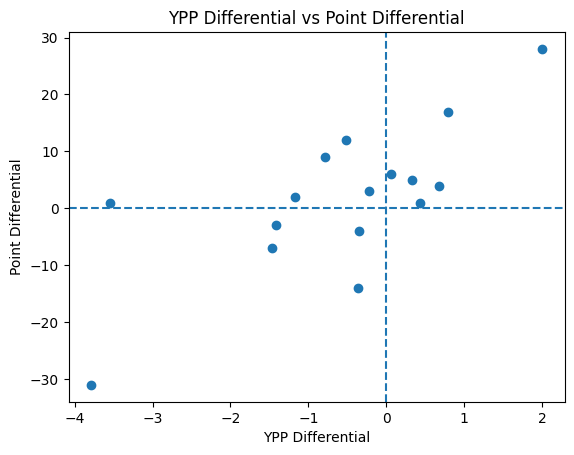

In [410]:
plt.scatter(game_stats["YPP_Diff"], game_stats["point_diff"])
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("YPP Differential")
plt.ylabel("Point Differential")
plt.title("YPP Differential vs Point Differential")
plt.show()

The model can currently expect to be off about 7 points. We should add another feature of importance to test and see if another feature can reduce mean error. Lower mean absoute error means our model is more accurate.

In [374]:
game_stats['chi_to'] = np.nan
game_stats['opp_to'] = np.nan
game_stats

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,NaN,NaN
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,NaN,NaN
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,NaN,NaN
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,NaN,NaN
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,NaN,NaN
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,NaN,NaN
6,8,5.17,5.53,False,-0.36,16,30,-14,3.210930,-17.210930,NaN,NaN
7,9,7.20,6.87,True,0.33,47,42,5,7.523408,-2.523408,NaN,NaN
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,NaN,NaN
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,NaN,NaN


In [375]:
# Loop through each week present in game_stats
for week_num in game_stats['Week'].unique():
    # Find the turnover data for the Bears for the current week
    # Note: 'Week' in regular_season_outcomes is float, so convert week_num to float for comparison
    chi_turnovers = regular_season_outcomes[regular_season_outcomes['Week'] == float(week_num)]['TO'].iloc[0]

    # Find the turnover data for the opponent for the current week
    opp_turnovers = opponent_regular_season_outcomes[opponent_regular_season_outcomes['Week'] == float(week_num)]['TO'].iloc[0]

    # Update the game_stats DataFrame
    mask = game_stats['Week'] == week_num
    game_stats.loc[mask, 'chi_to'] = chi_turnovers
    game_stats.loc[mask, 'opp_to'] = opp_turnovers

display(game_stats)

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,2.0,0.0
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,0.0,4.0
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,0.0,3.0
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,1.0,4.0
6,8,5.17,5.53,False,-0.36,16,30,-14,3.210930,-17.210930,1.0,0.0
7,9,7.20,6.87,True,0.33,47,42,5,7.523408,-2.523408,0.0,3.0
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,0.0,1.0
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,0.0,2.0


In [376]:
game_stats['turnover_margin'] = game_stats.apply(
    lambda row: row['chi_to'] - row['opp_to'], axis=1
)
game_stats

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to,turnover_margin
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0,0.0
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,2.0,0.0,2.0
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,0.0,4.0,-4.0
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0,-3.0
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,0.0,3.0,-3.0
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,1.0,4.0,-3.0
6,8,5.17,5.53,False,-0.36,16,30,-14,3.210930,-17.210930,1.0,0.0,1.0
7,9,7.20,6.87,True,0.33,47,42,5,7.523408,-2.523408,0.0,3.0,-3.0
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,0.0,1.0,-1.0
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,0.0,2.0,-2.0


Given the insights from Yards Per Play, let's now incorporate 'turnover margin' as another crucial feature. Turnovers often significantly swing the momentum and outcome of a game, even when other statistics might suggest a different result. By including this, we aim to further enhance our model's predictive power and reduce the Mean Absolute Error (MAE), moving towards a more accurate understanding of what drives a Bears' win.

In [377]:
X = game_stats[['YPP_Diff','turnover_margin']]
y = game_stats['point_diff']

In [378]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [379]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

score = model.score(X, y)
print("R^2:", score)

Coefficient: 3.9486500294565587
Intercept: -2.0400223053856683
R^2: 0.783471169062565


In [380]:
game_stats["predicted_point_diff_turnovers"] = model.predict(X)

In [381]:
game_stats["error_turnovers"] = game_stats["point_diff"] - game_stats["predicted_point_diff_turnovers"]

In [382]:
old_mae = np.mean(np.abs(game_stats["error"]))

new_mae = np.mean(np.abs(game_stats["error_turnovers"]))

print("Old MAE:", old_mae)

print("New MAE:", new_mae)

Old MAE: 7.125000325412605
New MAE: 4.919604942028946


In [383]:
print("New R^2:", model.score(X, y))

New R^2: 0.783471169062565


While yards-per-play differential served as a strong baseline predictor, incorporating turnover margin significantly improved model performance, reducing prediction error by approximately 30%. This suggests that turnovers play a critical role in determining game outcomes beyond efficiency metrics alone.

In [384]:
game_stats.sort_values(by="error_turnovers", ascending=False)

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to,turnover_margin,predicted_point_diff_turnovers,error_turnovers
11,13,4.81,5.60,True,-0.79,24,15,9,0.523444,8.476556,1.0,2.0,-1.0,-0.681240,9.681240
13,15,5.18,3.18,True,2.00,31,3,28,17.960853,10.039147,0.0,3.0,-3.0,19.291925,8.708075
10,12,4.90,5.12,True,-0.22,31,28,3,4.085926,-1.085926,2.0,2.0,0.0,-2.908725,5.908725
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0,0.0,-7.607619,4.607619
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0,-3.0,-2.623082,3.623082
14,16,5.83,5.77,True,0.06,22,16,6,5.835917,0.164083,0.0,1.0,-1.0,2.675113,3.324887
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,1.0,4.0,-3.0,9.341327,2.658673
12,14,4.57,6.04,False,-1.47,21,28,-7,-3.726534,-3.273466,1.0,1.0,0.0,-7.844538,0.844538
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,0.0,2.0,-2.0,2.296489,-0.296489
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,0.0,1.0,-1.0,5.123276,-1.123276


In [385]:
print(model.coef_)

[ 3.94865003 -4.47821583]


Having improved our model's accuracy by incorporating turnover margin, we now want to explore another potential feature: 'explosive plays'. To do this, we'll need to find and import an external play-by-play data source. We'll specifically look for plays with 20 or more yards gained, as these 'explosive plays' can significantly impact game momentum and outcomes, and we'll evaluate if this could be a valuable addition to our predictive model.

In [386]:
url = "https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.csv.gz"

df = pd.read_csv(url)

explosive = df[df["yards_gained"] >= 20]

/tmp/ipykernel_39935/514157850.py:3: DtypeWarning: Columns (45,179,180,182,183,189,190,203,204,205,206,218,219,220,222,224,226,233,234,235,236,237,238,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [387]:
explosive[
    (explosive['home_team'] == "CHI")]

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,run_location,run_gap,field_goal_result,kick_distance,extra_point_result,two_point_conv_result,home_timeouts_remaining,away_timeouts_remaining,timeout,timeout_team,td_team,td_player_name,td_player_id,posteam_timeouts_remaining,defteam_timeouts_remaining,total_home_score,total_away_score,posteam_score,defteam_score,score_differential,posteam_score_post,defteam_score_post,score_differential_post,no_score_prob,opp_fg_prob,opp_safety_prob,opp_td_prob,fg_prob,safety_prob,td_prob,extra_point_prob,two_point_conversion_prob,ep,epa,total_home_epa,total_away_epa,total_home_rush_epa,total_away_rush_epa,total_home_pass_epa,total_away_pass_epa,air_epa,yac_epa,comp_air_epa,comp_yac_epa,total_home_comp_air_epa,total_away_comp_air_epa,total_home_comp_yac_epa,total_away_comp_yac_epa,total_home_raw_air_epa,total_away_raw_air_epa,total_home_raw_yac_epa,total_away_raw_yac_epa,wp,def_wp,home_wp,away_wp,wpa,vegas_wpa,vegas_home_wpa,home_wp_post,away_wp_post,vegas_wp,vegas_home_wp,total_home_rush_wpa,total_away_rush_wpa,total_home_pass_wpa,total_away_pass_wpa,air_wpa,yac_wpa,comp_air_wpa,comp_yac_wpa,total_home_comp_air_wpa,total_away_comp_air_wpa,total_home_comp_yac_wpa,total_away_comp_yac_wpa,total_home_raw_air_wpa,total_away_raw_air_wpa,total_home_raw_yac_wpa,total_away_raw_yac_wpa,punt_blocked,first_down_rush,first_down_pass,first_down_penalty,third_down_converted,third_down_failed,fourth_down_converted,fourth_down_failed,incomplete_pass,touchback,interception,punt_inside_twenty,punt_in_endzone,punt_out_of_bounds,punt_downed,punt_fair_catch,kickoff_inside_twenty,kickoff_in_endzone,kickoff_out_of_bounds,kickoff_downed,kickoff_fair_catch,fumble_forced,fumble_not_forced,fumble_out_of_bounds,solo_tackle,safety,penalty,tackled_for_loss,fumble_lost,own_kickoff_recovery,own_kickoff_recovery_td,qb_hit,rush_attempt,pass_attempt,sack,touchdown,pass_touchdown,rush_touchdown,return_touchdown,extra_point_attempt,two_point_attempt,field_goal_attempt,kickoff_attempt,punt_attempt,fumble,complete_pass,assist_tackle,lateral_reception,lateral_rush,lateral_return,lateral_recovery,passer_player_id,passer_player_name,passing_yards,receiver_player_id,receiver_player_name,receiving_yards,rusher_player_id,rusher_player_name,rushing_yards,lateral_receiver_player_id,lateral_receiver_player_name,lateral_receiving_yards,lateral_rusher_player_id,lateral_rusher_player_name,lateral_rushing_yards,lateral_sack_player_id,lateral_sack_player_name,interception_player_id,interception_player_name,lateral_interception_player_id,lateral_interception_player_name,punt_returner_player_id,punt_returner_player_name,lateral_punt_returner_player_id,lateral_punt_returner_player_name,kickoff_returner_player_name,kickoff_returner_player_id,lateral_kickoff_returner_player_id,lateral_kickoff_returner_player_name,punter_player_id,punter_player_name,kicker_player_name,kicker_player_id,own_kickoff_recovery_player_id,own_kickoff_recovery_player_name,blocked_player_id,blocked_player_name,tackle_for_loss_1_player_id,tackle_for_loss_1_player_name,tackle_for_loss_2_player_id,tackle_for_loss_2_player_name,qb_hit_1_player_id,qb_hit_1_player_name,qb_hit_2_player_id,qb_hit_2_player_name,forced_fumble_player_1_team,forced_fumble_player_1_player_id,forced_fumble_player_1_player_name,forced_fumble_player_2_team,forced_fumble_player_2_player_id,forced_fumble_player_2_player_name,solo_tackle_1_team,solo_tackle_2_team,solo_tackle_1_player_id,solo_tackle_2_player_id,solo_tackle_1_player_name,solo_tackle_2_player_name,assist_tackle_1_player_id,assist_tackle_1_player_name,assist_tackle_1_team,assist_tack

In [388]:
explosive_plays_by_teams = explosive.groupby(['home_team', 'away_team']).size().reset_index(name='explosive_plays_count')
display(explosive_plays_by_teams)

,home_team,away_team,explosive_plays_count
0,ARI,ATL,8
1,ARI,CAR,7
2,ARI,GB,6
3,ARI,JAX,7
4,ARI,LA,10
...,...,...,...
276,WAS,DET,7
277,WAS,LV,7
278,WAS,NYG,6
279,WAS,PHI,7


In [389]:
explosive_bears = explosive_plays_by_teams[explosive_plays_by_teams['home_team'] == 'CHI']

In [390]:
# Calculate explosive plays for the Bears per week
bears_explosive_for_week = explosive[explosive['posteam'] == 'CHI'].groupby('week').size().reset_index(name='bears_explosive_for')

# Calculate explosive plays against the Bears per week
bears_explosive_against_week = explosive[explosive['defteam'] == 'CHI'].groupby('week').size().reset_index(name='bears_explosive_against')

# Merge these two DataFrames on 'week'
bears_explosive_summary = pd.merge(
    bears_explosive_for_week,
    bears_explosive_against_week,
    on='week',
    how='outer'
)

# Fill any NaN values (weeks where there were no plays for/against) with 0
bears_explosive_summary['bears_explosive_for'] = bears_explosive_summary['bears_explosive_for'].fillna(0).astype(int)
bears_explosive_summary['bears_explosive_against'] = bears_explosive_summary['bears_explosive_against'].fillna(0).astype(int)

# Display the result
display(bears_explosive_summary.sort_values(by='week'))

,week,bears_explosive_for,bears_explosive_against
0,1,3,2
1,2,5,7
2,3,5,5
3,4,2,3
4,6,4,3
5,7,5,4
6,8,6,5
7,9,6,10
8,10,6,6
9,11,2,2


In [391]:
regular_season_bears_explosive = bears_explosive_summary.iloc[:14, :]
regular_season_bears_explosive

,week,bears_explosive_for,bears_explosive_against
0,1,3,2
1,2,5,7
2,3,5,5
3,4,2,3
4,6,4,3
5,7,5,4
6,8,6,5
7,9,6,10
8,10,6,6
9,11,2,2


In [392]:
game_stats = pd.merge(
    game_stats,
    regular_season_bears_explosive[['week', 'bears_explosive_for', 'bears_explosive_against']],
    left_on='Week',
    right_on='week',
    how='left'
)

# Drop the redundant 'week' column which is from bears_explosive_summary
# This column was added during the merge and is now redundant with 'Week'
if 'week' in game_stats.columns:
    game_stats = game_stats.drop(columns=['week'])

# Fill any NaN values that might arise from missing explosive play data with 0
# This ensures the calculation of explosive_play_margin doesn't produce NaNs
game_stats['bears_explosive_for'] = game_stats['bears_explosive_for'].fillna(0).astype(int)
game_stats['bears_explosive_against'] = game_stats['bears_explosive_against'].fillna(0).astype(int)

game_stats['explosive_play_margin'] = game_stats.apply(
    lambda row: row['bears_explosive_for'] - row['bears_explosive_against'], axis=1
)

By incorporating 'margin_explosive' into our model alongside 'YPP_Diff' and 'margin_to', we have further refined its predictive capability. Let's analyze the new MAE and R-squared to determine the extent of this improvement and discuss what this means for understanding game outcomes.

In [393]:
X = game_stats[['YPP_Diff', 'turnover_margin', 'explosive_play_margin']]
y = game_stats['point_diff']

In [394]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [395]:
print("Coefficient YPP_Diff:", model.coef_[0])
print("Coefficient margin_to:", model.coef_[1])
print("Coefficient margin_explosive:", model.coef_[2])
print("Intercept:", model.intercept_)

score = model.score(X, y)
print("R^2:", score)

Coefficient YPP_Diff: 3.3206404565887007
Coefficient margin_to: -4.629814884055992
Coefficient margin_explosive: 1.348747691559046
Intercept: -2.3621814068760134
R^2: 0.8035897227737185


In [396]:
game_stats["predicted_point_diff_final"] = model.predict(X)

In [397]:
game_stats["error_final"] = game_stats["point_diff"] - game_stats["predicted_point_diff_final"]

In [398]:
mae_with_explosive = np.mean(np.abs(game_stats["error_final"]))

print("Old MAE (YPP_Diff only):", old_mae)
print("MAE with Turnover Margin:", new_mae)
print("MAE with Turnover Margin and Explosive Plays:", mae_with_explosive)
print("New R^2 with Turnover Margin and Explosive Plays:", model.score(X, y))

Old MAE (YPP_Diff only): 7.125000325412605
MAE with Turnover Margin: 4.919604942028946
MAE with Turnover Margin and Explosive Plays: 4.401564816588311
New R^2 with Turnover Margin and Explosive Plays: 0.8035897227737185


In [399]:
game_stats = game_stats.copy()

# Initialize new columns for 3rd down conversion percentages
game_stats['chi_3rd_percent'] = np.nan
game_stats['opp_3rd_percent'] = np.nan

# Loop through each week present in game_stats to populate 3rd down conversion data
for week_num in game_stats['Week'].unique():
    # Retrieve Bears' 3rd down conversions and attempts for the current week
    # Note: 'Week' in regular_season_outcomes is float, so convert week_num to float for comparison
    chi_3rd_conv = regular_season_outcomes[regular_season_outcomes['Week'] == float(week_num)]['3DConv'].iloc[0]
    chi_3rd_att = regular_season_outcomes[regular_season_outcomes['Week'] == float(week_num)]['3DAtt'].iloc[0]

    # Retrieve opponent's 3rd down conversions and attempts for the current week
    opp_3rd_conv = opponent_regular_season_outcomes[opponent_regular_season_outcomes['Week'] == float(week_num)]['3DConv'].iloc[0]
    opp_3rd_att = opponent_regular_season_outcomes[opponent_regular_season_outcomes['Week'] == float(week_num)]['3DAtt'].iloc[0]

    # Calculate conversion percentages, handling division by zero
    chi_3rd_percent = chi_3rd_conv / chi_3rd_att if chi_3rd_att > 0 else 0.0
    opp_3rd_percent = opp_3rd_conv / opp_3rd_att if opp_3rd_att > 0 else 0.0

    # Update the game_stats DataFrame
    mask = game_stats['Week'] == week_num
    game_stats.loc[mask, 'chi_3rd_percent'] = chi_3rd_percent
    game_stats.loc[mask, 'opp_3rd_percent'] = opp_3rd_percent

display(game_stats)

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to,turnover_margin,predicted_point_diff_turnovers,error_turnovers,bears_explosive_for,bears_explosive_against,explosive_play_margin,predicted_point_diff_final,error_final,chi_3rd_percent,opp_3rd_percent
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0,0.0,-7.607619,4.607619,3,2,1,-5.695537,2.695537,0.250000,0.250000
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,2.0,0.0,2.0,-25.961838,-5.038162,5,7,-2,-26.904534,-4.095466,0.538462,0.400000
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,0.0,4.0,-4.0,18.992275,-1.992275,5,5,0,18.780384,-1.780384,0.571429,0.272727
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0,-3.0,-2.623082,3.623082,2,3,-1,-1.609758,2.609758,0.437500,0.250000
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,0.0,3.0,-3.0,13.092545,-12.092545,4,3,1,14.303886,-13.303886,0.300000,0.375000
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,1.0,4.0,-3.0,9.341327,2.658673,5,4,1,11.149278,0.850722,0.250000,0.300000
6,8,5.17,5.53,False,-0.36,16,30,-14,3.210930,-17.210930,1.0,0.0,1.0,-7.939752,-6.060248,6,5,1,-6.838679,-7.161321,0.461538,0.400000
7,9,7.20,6.87,True,0.33,47,42,5,7.523408,-2.523408,0.0,3.0,-3.0,12.697680,-7.697680,6,10,-4,7.228084,-2.228084,0.533333,0.500000
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,0.0,1.0,-1.0,5.123276,-1.123276,6,6,0,4.525669,-0.525669,0.272727,0.357143
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,0.0,2.0,-2.0,2.296489,-0.296489,2,2,0,3.012299,-1.012299,0.388889,0.272727


In [400]:
game_stats['margin_3rd_percent'] = game_stats.apply(
    lambda row: row['chi_3rd_percent'] - row['opp_3rd_percent'], axis=1
)
display(game_stats)

,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to,turnover_margin,predicted_point_diff_turnovers,error_turnovers,bears_explosive_for,bears_explosive_against,explosive_play_margin,predicted_point_diff_final,error_final,chi_3rd_percent,opp_3rd_percent,margin_3rd_percent
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0,0.0,-7.607619,4.607619,3,2,1,-5.695537,2.695537,0.250000,0.250000,0.000000
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,2.0,0.0,2.0,-25.961838,-5.038162,5,7,-2,-26.904534,-4.095466,0.538462,0.400000,0.138462
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,0.0,4.0,-4.0,18.992275,-1.992275,5,5,0,18.780384,-1.780384,0.571429,0.272727,0.298701
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0,-3.0,-2.623082,3.623082,2,3,-1,-1.609758,2.609758,0.437500,0.250000,0.187500
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,0.0,3.0,-3.0,13.092545,-12.092545,4,3,1,14.303886,-13.303886,0.300000,0.375000,-0.075000
5,7,4.94,5.46,True,-0.52,26,14,12,2.210935,9.789065,1.0,4.0,-3.0,9.341327,2.658673,5,4,1,11.149278,0.850722,0.250000,0.300000,-0.050000
6,8,5.17,5.53,False,-0.36,16,30,-14,3.210930,-17.210930,1.0,0.0,1.0,-7.939752,-6.060248,6,5,1,-6.838679,-7.161321,0.461538,0.400000,0.061538
7,9,7.20,6.87,True,0.33,47,42,5,7.523408,-2.523408,0.0,3.0,-3.0,12.697680,-7.697680,6,10,-4,7.228084,-2.228084,0.533333,0.500000,0.033333
8,10,6.46,5.78,True,0.68,24,20,4,9.710896,-5.710896,0.0,1.0,-1.0,5.123276,-1.123276,6,6,0,4.525669,-0.525669,0.272727,0.357143,-0.084416
9,11,3.65,4.82,True,-1.17,19,17,2,-1.851543,3.851543,0.0,2.0,-2.0,2.296489,-0.296489,2,2,0,3.012299,-1.012299,0.388889,0.272727,0.116162


Now that we have the 'margin_3rd' for third down conversions, let's incorporate this feature into our linear regression model to see if it further improves its predictive power. We will retrain the model with 'YPP_Diff', 'margin_to', 'margin_explosive', and 'margin_3rd' as predictors and assess the new MAE and R-squared values.

In [401]:
X = game_stats[['YPP_Diff', 'turnover_margin', 'explosive_play_margin', 'margin_3rd_percent']]
y = game_stats['point_diff']

In [402]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [403]:
print("Coefficient YPP_Diff:", model.coef_[0])
print("Coefficient margin_to:", model.coef_[1])
print("Coefficient margin_explosive:", model.coef_[2])
print("Coefficient margin_3rd_percent:", model.coef_[3])
print("Intercept:", model.intercept_)

score = model.score(X, y)
print("R^2:", score)

Coefficient YPP_Diff: 3.612092799897733
Coefficient margin_to: -4.362913250559926
Coefficient margin_explosive: 1.331301656454881
Coefficient margin_3rd_percent: 6.943458956885942
Intercept: -1.9421430195962315
R^2: 0.8101914007392313


In [404]:
game_stats["new_predict_3rd_down"] = model.predict(X)

In [405]:
game_stats["new_error_3rd_down"] = game_stats["point_diff"] - game_stats["new_predict_3rd_down"]

In [406]:
columns_to_drop = ['chi_3rd', 'opp_3rd', 'margin_3rd']

# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in game_stats.columns]

if existing_columns_to_drop:
    game_stats = game_stats.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("No specified columns found to drop.")

display(game_stats.head())

No specified columns found to drop.


,Week,Chi,Opp,Win,YPP_Diff,chi_pts,opp_pts,point_diff,predicted_point_diff,error,chi_to,opp_to,turnover_margin,predicted_point_diff_turnovers,error_turnovers,bears_explosive_for,bears_explosive_against,explosive_play_margin,predicted_point_diff_final,error_final,chi_3rd_percent,opp_3rd_percent,margin_3rd_percent,new_predict_3rd_down,new_error_3rd_down
0,1,4.57,5.98,False,-1.41,24,27,-3,-3.351536,0.351536,1.0,1.0,0.0,-7.607619,4.607619,3,2,1,-5.695537,2.695537,0.250000,0.250000,0.000000,-5.703892,2.703892
1,2,4.73,8.52,False,-3.79,21,52,-31,-18.226458,-12.773542,2.0,0.0,2.0,-25.961838,-5.038162,5,7,-2,-26.904534,-4.095466,0.538462,0.400000,0.138462,-26.059003,-4.940997
2,3,6.47,5.68,True,0.79,31,14,17,10.398393,6.601607,0.0,4.0,-4.0,18.992275,-1.992275,5,5,0,18.780384,-1.780384,0.571429,0.272727,0.298701,20.437084,-3.437084
3,4,2.99,6.54,True,-3.55,25,24,1,-16.726466,17.726466,1.0,4.0,-3.0,-2.623082,3.623082,2,3,-1,-1.609758,2.609758,0.437500,0.250000,0.187500,-1.705736,2.705736
4,6,5.73,5.30,True,0.43,25,24,1,8.148405,-7.148405,0.0,3.0,-3.0,13.092545,-12.092545,4,3,1,14.303886,-13.303886,0.300000,0.375000,-0.075000,13.510339,-12.510339


In [407]:
game_stats["new_error_3rd_down"] = game_stats["point_diff"] - game_stats["new_predict_3rd_down"]
mae_with_3rd_down = np.mean(np.abs(game_stats["new_error_3rd_down"]))

print("Old MAE (YPP_Diff only):", old_mae)
print("MAE with Turnover Margin:", new_mae)
print("MAE with Turnover Margin and Explosive Plays:", mae_with_explosive)
print("MAE with Turnover Margin, Explosive Plays, and 3rd Down Percent Margin:", mae_with_3rd_down)
print("New R^2 with Turnover Margin, Explosive Plays, and 3rd Down Percent Margin:", model.score(X, y))

Old MAE (YPP_Diff only): 7.125000325412605
MAE with Turnover Margin: 4.919604942028946
MAE with Turnover Margin and Explosive Plays: 4.401564816588311
MAE with Turnover Margin, Explosive Plays, and 3rd Down Percent Margin: 4.5886540535531175
New R^2 with Turnover Margin, Explosive Plays, and 3rd Down Percent Margin: 0.8101914007392313


It's interesting to note that while the R-squared value slightly increased to 0.811, indicating that the model explains a bit more of the variance in point differential, the Mean Absolute Error (MAE) also slightly increased from 4.441 to 4.627.

This suggests that while the 3rd down conversion margin might contribute to the overall explanatory power of the model, it doesn't necessarily improve the average accuracy of the predictions in terms of point differential in this linear combination. It could be due to various reasons, such as multicollinearity with existing features, or the feature's impact being non-linear or conditional on other game factors not captured by this simple linear model.

The best situation is to assume the model is to rely on the first three features rather than adding the fourth.

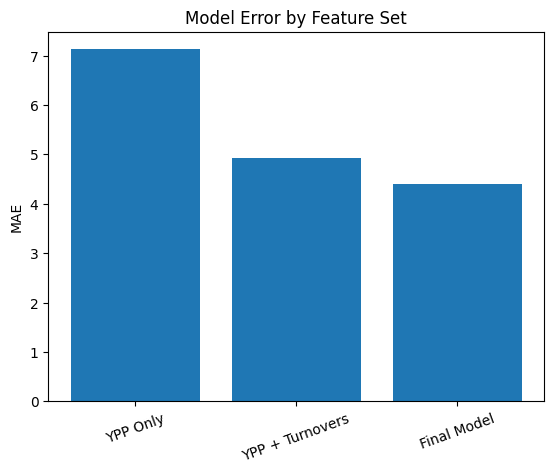

In [408]:
mae_scores = {
    "YPP Only": old_mae,
    "YPP + Turnovers": new_mae,
    "Final Model": mae_with_explosive
}

plt.bar(mae_scores.keys(), mae_scores.values())
plt.ylabel("MAE")
plt.title("Model Error by Feature Set")
plt.xticks(rotation=20)
plt.show()